# 00 — Design Goals & Mission Profile

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** State what the box has to do, before any converter design. The indoor-air
requirement sets airflow; airflow sets the fan and filter choice; that sets the electrical
load and the duty profile the converter is optimized against. Every assumption made before
the build is then checked against the 2026-09-15 measurements.

**Design basis (V1):** 1250 sq ft × 8 ft house (10,000 ft³). 2–3 ACH continuous, 4–6 ACH
during wildfire smoke or high-heat indoor cooking. Two units so that rooms with poor
inter-room mixing are each served; each unit is 10 × Arctic P14 Pro behind two 3M Filtrete
1900 16×25 filters, in the two-filter arrangement used by Clean Air Kit-style builds.
Powered from a USB-C supply the owner already has.

**Key result — decision:** three of the four pre-build load assumptions are wrong, all in
the same direction — the load at low speed is larger than assumed.

1. **The array does not draw 42 W.** At 100 % PWM the ten fans draw **35.4 W** on the
   12 V rail (measured, extrapolated from 34.4 W at 98.8 %). The 42 W nameplate
   (10 × 0.35 A × 12 V) sits 18 % above that. The nameplate stays the *sizing* basis — it
   errs conservative — but it is not the load.
2. **Fan power does not follow the cube of PWM duty.** Measured, P ∝ PWM^1.56, or
   P ∝ rpm^2.07. The quiet setting costs **4.3 W, not 1.5 W** — 2.8×.
3. **The mission profile therefore averages 5.0 W, not 2.35 W.** Lifetime electricity
   roughly doubles, from $4.12 to $8.75 a year of delivered energy. This is an input to
   Objective 2 (notebook 09), and it does not change that objective's expected
   BOM-dominated conclusion.
4. **The supply sets achievable speed; it is not a design requirement.** The 65 W
   chargers on hand are *fan*-limited, not source-limited — full speed with ~29 W to
   spare. The binding source is a plain 5 V / 3 A battery bank, on which the board
   measured 64 % PWM, essentially the intended 67 % "high" setting. That corner is
   Objective 1.

**Measurement caveat on all of the above:** the ten fans were run **in open air on the
bench**, not in the assembled enclosure behind filters, and the 5 V and 9 V runs never
reached 100 % PWM. Section 7 says what that could change and what settles it.

**See also:** 01 (electrical operating envelope and loss budget), 02 (measured fan
commutation current — the real load waveform), 11 (measured vs modeled efficiency),
`measurements/efficiency/README.md` (test setup and calibration caveats), README
(optimization objectives).

## 1. The requirement: clean air, quietly

The need is seasonal wildfire smoke and the particulate from high-heat indoor cooking —
both PM2.5 sources that arrive fast and last days. Three constraints shaped everything
downstream:

- **Quiet enough to sleep through.** The unit runs in occupied rooms overnight. An
  air purifier that gets switched off at night does not clean air at night.
- **Consumer PC fans.** A large, competitive market means many quiet, well-characterised,
  cheap options with published PWM curves — and replacements in five years.
- **Low power, from a USB-C supply.** Partly efficiency, but mostly *legibility*: "it
  draws about what charging a laptop draws" is a claim a non-technical person can accept
  without being walked through a power budget.

**Prior art.** The two-filter arrangement (filters on opposite faces, fans blowing through)
follows Clean Air Kit-style builds, and the airflow calculator at
[redheadhandicrafts.com](https://tutorials.redheadhandicrafts.com/portable-air-purifier/)
sized the fan count. That build powers its fans from a USB-PD trigger board set to 12 V.
This project does not, for two reasons: **12 V is not a required PD voltage** (a source
only has to offer 5 V, and 9/15/20 V above 15 W), so a 12 V trigger works only with the
subset of chargers that happen to implement it; and **a trigger board is a passthrough**,
so the fans' commutation current pulses (notebook 02) land directly on the supply and its
cable. A regulated converter with bulk output capacitance decouples both.

## 2. From air changes to airflow

Air changes per hour (ACH) is the requirement people actually specify for particulate
removal. Converting to the CFM that fans are rated in is just the room volume.

In [1]:
import sys; sys.path.insert(0, '..')                                   # repo root: constants.py
sys.path.insert(0, '../measurements/test setup/efficiency_esp32')      # efficiency analysis tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import constants as cfg

pd.set_option('display.width', 200)

# --- house ---
FLOOR_AREA_SQFT = 1250
CEILING_FT      = 8.0
VOLUME_FT3      = FLOOR_AREA_SQFT * CEILING_FT
CFM_PER_ACH     = VOLUME_FT3 / 60.0          # 1 ACH = one volume per hour = V/60 CFM

# --- air-change targets ---
ACH_CONTINUOUS = (2, 3)     # background, all the time
ACH_PEAK       = (4, 6)     # wildfire smoke, cooking, illness in the house
N_UNITS        = 2          # separate rooms; inter-room mixing is not assumed

print(f"House volume          : {FLOOR_AREA_SQFT:.0f} sq ft x {CEILING_FT:.0f} ft = {VOLUME_FT3:,.0f} ft^3")
print(f"1 ACH                 : {CFM_PER_ACH:.0f} CFM\n")

rows = []
for label, (lo, hi) in (('continuous', ACH_CONTINUOUS), ('peak', ACH_PEAK)):
    rows.append({'mode': label, 'ACH_target': f"{lo}-{hi}",
                 'house_CFM': f"{lo*CFM_PER_ACH:.0f}-{hi*CFM_PER_ACH:.0f}",
                 'per_unit_CFM': f"{lo*CFM_PER_ACH/N_UNITS:.0f}-{hi*CFM_PER_ACH/N_UNITS:.0f}"})
print(pd.DataFrame(rows).to_string(index=False))

# The per-unit design point chosen from the ranges above
UNIT_CFM_CONTINUOUS = 166.0
UNIT_CFM_HIGH       = 500.0
print(f"\nPer-unit design point : {UNIT_CFM_CONTINUOUS:.0f} CFM continuous, {UNIT_CFM_HIGH:.0f} CFM high")
print(f"  {N_UNITS} units -> {N_UNITS*UNIT_CFM_CONTINUOUS:.0f} CFM = "
      f"{N_UNITS*UNIT_CFM_CONTINUOUS/CFM_PER_ACH:.1f} ACH continuous")
print(f"  {N_UNITS} units -> {N_UNITS*UNIT_CFM_HIGH:.0f} CFM = "
      f"{N_UNITS*UNIT_CFM_HIGH/CFM_PER_ACH:.1f} ACH peak")

House volume          : 1250 sq ft x 8 ft = 10,000 ft^3
1 ACH                 : 167 CFM

      mode ACH_target house_CFM per_unit_CFM
continuous        2-3   333-500      167-250
      peak        4-6  667-1000      333-500

Per-unit design point : 166 CFM continuous, 500 CFM high
  2 units -> 332 CFM = 2.0 ACH continuous
  2 units -> 1000 CFM = 6.0 ACH peak


## 3. Fan and filter choice

Ten Arctic P14 Pro behind two 3M Filtrete 1900 16×25 filters, per unit. The
redheadhandicrafts airflow calculator gave a **832 CFM theoretical peak** for that
combination, reaching the 166 CFM continuous and 500 CFM high targets at roughly **33 %
and 67 %** respectively. From experience with the assembled unit, 33 % is very quiet and
67 % is acceptable but audible — which is what makes them the two mission-profile settings.

Ten fans × 0.35 A × 12 V = **42 W**, the number in the project's name. That is a nameplate
figure; section 4 measures the real one.

## 4. What the speed settings actually cost

Everything above was assumed before the build. The 2026-09-15 efficiency runs logged PWM
duty, per-fan current and tachometer speed alongside input and output power, so the load
model can be checked directly. The 15 V and 20 V runs both sweep the full 0 → 100 → 0 %
ramp and agree closely, so they are pooled here.

Source: `measurements/efficiency/2026-09-15_141025_fans_15V.csv` and `..._141459_fans_20V.csv`,
loaded and DMM-calibrated by the same code the plotting scripts use
(`plot_efficiency.load`). Caveats in `measurements/efficiency/README.md`.

In [2]:
from calibrate_shunts import load_calibration
from plot_efficiency import load

MEAS = '../measurements/efficiency/'
CAL  = [MEAS + '2026-09-15_133151_shunt_cal_in.csv',
        MEAS + '2026-09-15_154613_shunt_cal_fan12.csv::b5in']
RUNS = {5:  '2026-09-15_151555_fans_5V.csv',  9:  '2026-09-15_151955_fans_9V.csv',
        15: '2026-09-15_141025_fans_15V.csv', 20: '2026-09-15_141459_fans_20V.csv'}

cal  = load_calibration(CAL)
runs = {v: load(MEAS + f, cal)[1] for v, f in RUNS.items()}     # [1] = active (PWM > 0) rows

# Pool the two runs that reach 100 % PWM; drop the start transient below 12 %.
full = pd.concat([runs[15].assign(vin=15), runs[20].assign(vin=20)])
full = full[full.pwm_pct > 12]
g    = full.groupby(pd.cut(full.pwm_pct, np.arange(10, 105, 2.5), right=False), observed=True)
pwm_curve = g.agg(pwm=('pwm_pct', 'mean'), P_fans=('P_fans', 'mean'),
                  rpm=('rpm_median', 'mean'), n=('P_fans', 'size'))
pwm_curve = pwm_curve[pwm_curve.n >= 6].reset_index(drop=True)

# 100 % PWM is the last 1.2 % of the ramp; take it from a cubic fit rather than the last bin.
fit_pwm = np.polyfit(pwm_curve.pwm, pwm_curve.P_fans, 3)
P_FANS_100 = float(np.polyval(fit_pwm, 100.0))
RPM_MAX    = float(pwm_curve.rpm.max())
P_HOUSEKEEPING = float(full.P_b5in.mean())     # 5 V buck input, constant across the ramp

NAMEPLATE_W = cfg.MAX_FAN_LOAD_WATTS           # 10 x 0.35 A x 12 V = 42 W

print(f"measured fan-rail power at 98.8 % PWM : {pwm_curve.P_fans.iloc[-1]:.2f} W")
print(f"cubic fit extrapolated to 100 %       : {P_FANS_100:.2f} W")
print(f"nameplate (constants.MAX_FAN_LOAD_WATTS): {NAMEPLATE_W:.2f} W")
print(f"  -> nameplate is {100*(NAMEPLATE_W/P_FANS_100 - 1):.0f} % above the measured load")
print(f"max tach speed seen                   : {RPM_MAX:.0f} rpm")
print(f"5 V housekeeping buck, input power    : {P_HOUSEKEEPING:.3f} W (constant)")

# Power-law exponents. The affinity law P ~ N^3 would give 3.00 against speed.
for x, name in ((pwm_curve.pwm, 'PWM %'), (pwm_curve.rpm, 'rpm')):
    n_exp = np.polyfit(np.log(x), np.log(pwm_curve.P_fans), 1)[0]
    print(f"  P_fans ~ ({name})^{n_exp:.2f}")

measured fan-rail power at 98.8 % PWM : 34.44 W
cubic fit extrapolated to 100 %       : 35.44 W
nameplate (constants.MAX_FAN_LOAD_WATTS): 42.00 W
  -> nameplate is 18 % above the measured load
max tach speed seen                   : 2828 rpm
5 V housekeeping buck, input power    : 0.437 W (constant)
  P_fans ~ (PWM %)^1.56
  P_fans ~ (rpm)^2.07


Two separate effects break the cube model, and they compound:

- **PWM duty is not speed fraction.** These fans have a minimum speed: 33 % duty runs them
  at ~1140 rpm, which is 40 % of the 2828 rpm maximum, not 33 %.
- **Shaft power is not the whole load.** Against *speed*, the exponent is 2.07, not 3.
  The fan's own driver electronics, bearing friction and commutation losses are roughly
  fixed, so at low speed they dominate a shaft power that is falling as N³.

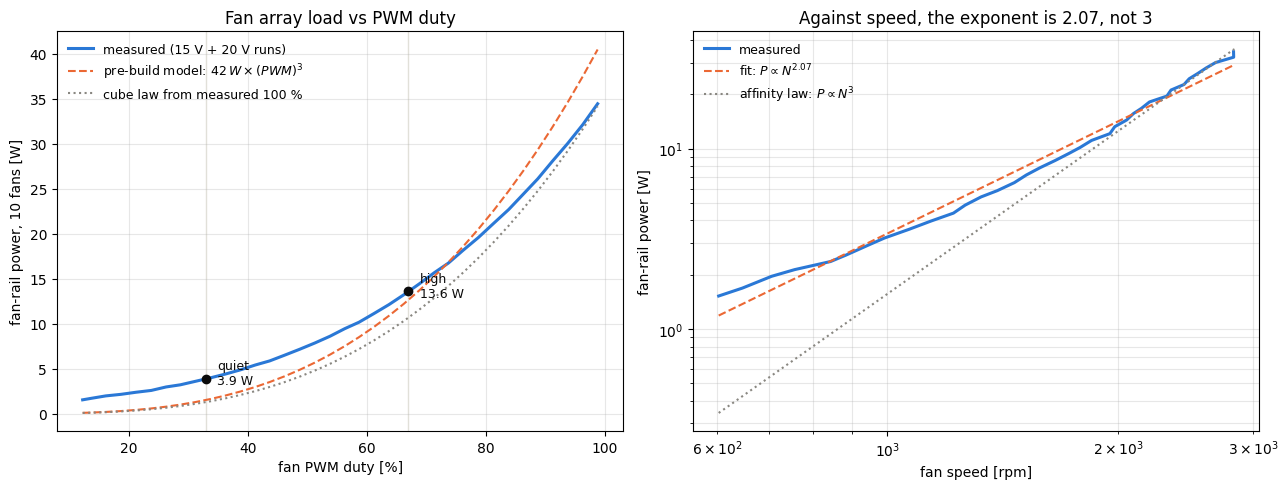

In [3]:
f = pwm_curve.pwm / 100.0
cube_nameplate = NAMEPLATE_W * f**3          # the pre-build model
cube_measured  = P_FANS_100  * f**3          # cube law, but anchored to the measured 100 % point

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(pwm_curve.pwm, pwm_curve.P_fans, lw=2.2, color='#2a78d6', label='measured (15 V + 20 V runs)')
ax1.plot(pwm_curve.pwm, cube_nameplate, ls='--', color='#eb6834', label=r'pre-build model: $42\,W\times(PWM)^3$')
ax1.plot(pwm_curve.pwm, cube_measured, ls=':', color='#898781', label=r'cube law from measured 100 %')
for pwm_pt, lbl in ((33, 'quiet'), (67, 'high')):
    p = np.interp(pwm_pt, pwm_curve.pwm, pwm_curve.P_fans)
    ax1.plot([pwm_pt], [p], 'o', color='#0b0b0b', ms=6, zorder=5)
    ax1.annotate(f'{lbl}\n{p:.1f} W', (pwm_pt, p), textcoords='offset points', xytext=(8, -4),
                 fontsize=9, color='#0b0b0b')
    ax1.axvline(pwm_pt, color='#e1e0d9', lw=1, zorder=0)
ax1.set_xlabel('fan PWM duty [%]'); ax1.set_ylabel('fan-rail power, 10 fans [W]')
ax1.set_title('Fan array load vs PWM duty')
ax1.legend(fontsize=9, frameon=False); ax1.grid(alpha=0.3)

ax2.loglog(pwm_curve.rpm, pwm_curve.P_fans, lw=2.2, color='#2a78d6', label='measured')
n_rpm = np.polyfit(np.log(pwm_curve.rpm), np.log(pwm_curve.P_fans), 1)
ax2.loglog(pwm_curve.rpm, np.exp(np.polyval(n_rpm, np.log(pwm_curve.rpm))),
           ls='--', color='#eb6834', label=fr'fit: $P\propto N^{{{n_rpm[0]:.2f}}}$')
ax2.loglog(pwm_curve.rpm, P_FANS_100 * (pwm_curve.rpm / RPM_MAX)**3,
           ls=':', color='#898781', label=r'affinity law: $P\propto N^{3}$')
ax2.set_xlabel('fan speed [rpm]'); ax2.set_ylabel('fan-rail power [W]')
ax2.set_title('Against speed, the exponent is 2.07, not 3')
ax2.legend(fontsize=9, frameon=False); ax2.grid(alpha=0.3, which='both')

fig.tight_layout()
fig.savefig('../figures/00_fan_load_vs_pwm.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Mission profile

The profile is an estimate of how the unit is actually used: essentially always on quiet,
about two hours a week on high, and a little time at full speed. It is the weighting for
Objective 2 (BOM + lifetime electricity, notebook 09). Recomputing it with measured load
instead of the cube model is the point of this section.

In [4]:
# Duty split: ~2 h/week high out of 168 h, the rest quiet, with a little at full speed.
PROFILE = [
    # PWM %, duty fraction, label
    ( 33, 0.95, 'quiet / continuous'),
    ( 67, 0.04, 'high  (~7 h/week)'),
    (100, 0.01, 'peak  (~2 h/week)'),
]
ASSUMED_W = {33: 1.5, 67: 12.6, 100: 42.0}       # README / CLAUDE.md, from 42 W x (PWM)^3

rows = []
for pwm_pt, duty, label in PROFILE:
    p_fans = P_FANS_100 if pwm_pt == 100 else float(np.interp(pwm_pt, pwm_curve.pwm, pwm_curve.P_fans))
    rows.append({'PWM_pct': pwm_pt, 'use': label, 'duty': duty,
                 'assumed_W': ASSUMED_W[pwm_pt],
                 'meas_fans_W': round(p_fans, 2),
                 'meas_total_W': round(p_fans + P_HOUSEKEEPING, 2),
                 'ratio': round((p_fans + P_HOUSEKEEPING) / ASSUMED_W[pwm_pt], 2)})
prof = pd.DataFrame(rows)
print(prof.to_string(index=False))

avg_assumed = float((prof.assumed_W * prof.duty).sum())
avg_meas    = float((prof.meas_total_W * prof.duty).sum())
kwh         = lambda w: w * cfg.HOURS_PER_YEAR / 1000.0
usd         = lambda w: kwh(w) * cfg.ELECTRICITY_USD_PER_KWH

print(f"\n{'':22s}{'avg power':>12s}{'kWh/yr':>10s}{'$/yr':>9s}{'$/10 yr':>10s}")
for label, w in (('assumed (cube law)', avg_assumed), ('measured', avg_meas)):
    print(f"{label:22s}{w:9.2f} W{kwh(w):10.1f}{usd(w):9.2f}{usd(w)*10:10.2f}")
print(f"\nmeasured / assumed: {avg_meas/avg_assumed:.2f}x")
print("\nThese are DELIVERED energy at the 12 V rail. Energy drawn from the wall is higher")
print("by 1/eta; at the quiet point the converter measures ~95-96 % (notebook 11), so the")
print("wall figure is roughly 4-5 % above these numbers, plus the USB supply's own loss.")

 PWM_pct                use  duty  assumed_W  meas_fans_W  meas_total_W  ratio
      33 quiet / continuous  0.95        1.5         3.85          4.29   2.86
      67  high  (~7 h/week)  0.04       12.6        13.57         14.01   1.11
     100  peak  (~2 h/week)  0.01       42.0        35.44         35.88   0.85

                         avg power    kWh/yr     $/yr   $/10 yr
assumed (cube law)         2.35 W      20.6     4.12     41.15
measured                   4.99 W      43.8     8.75     87.51

measured / assumed: 2.13x

These are DELIVERED energy at the 12 V rail. Energy drawn from the wall is higher
by 1/eta; at the quiet point the converter measures ~95-96 % (notebook 11), so the
wall figure is roughly 4-5 % above these numbers, plus the USB supply's own loss.


The profile average roughly doubles. The consequence for Objective 2 is a **larger
electricity term than the README states — about $8.75/yr of delivered energy instead of
$4.12** — but the direction of that objective's expected conclusion is unchanged. Candidate
parts in notebooks 03 and 04 differ by tens of milliwatts *at the 15 W design point*, and
the profile spends 95 % of its hours at roughly a quarter of that current, where I²R
differences shrink by ~16×. The operational-cost optimum is still expected to be
BOM-dominated. Notebook 09 settles it.

Note also that the 5 V housekeeping buck draws a constant **0.44 W**, which is 10 % of the
load at the quiet setting and, unlike the fans, does not scale down at all. At the mission
profile's weighting it is a larger share of lifetime energy than any power-stage part
choice considered in 03 or 04. It was never in scope for V1 and is not analysed anywhere
in this repo — a V2 item.

## 6. What the supplies on hand can deliver

**The load and the two speed settings are the design targets; whichever supply the owner
plugs in sets the maximum speed available.** A supply that reaches the 67 % high setting
satisfies the mission profile, and reaching 100 % is a bonus. No part of the converter
design is conditioned on owning a particular wattage of charger.

Supplies actually on hand: several 65 W PD chargers, one 30 W, a few 20 W, and USB battery
banks with no PD (5 V / 3 A). Efficiency below is measured at the closest logged operating
point on the matching-voltage run; the achievable PWM comes from the measured load curve
of section 4.

In [5]:
SUPPLIES = [
    # label,                              PD leg used, V, A
    ('65 W PD  (several owned)',          20, 3.25),
    ('30 W PD  (one owned)',              20, 1.50),
    ('20 W PD  (a few owned)',             9, 2.22),
    ('battery bank, no PD',                5, 3.00),
]
P_OUT_MAX = P_FANS_100 + P_HOUSEKEEPING

rows = []
for label, v, i in SUPPLIES:
    p_src = v * i
    act   = runs[v]
    eta   = float(act.loc[(act.P_in - min(p_src, act.P_in.max())).abs().idxmin(), 'eta'])
    p_out = min(p_src * eta, P_OUT_MAX)
    p_fan = max(p_out - P_HOUSEKEEPING, 0.01)
    pwm   = 100.0 if p_fan >= P_FANS_100 else float(np.interp(p_fan, pwm_curve.P_fans, pwm_curve.pwm))
    rows.append({'supply': label, 'V_in': v, 'I_limit_A': i, 'P_source_W': p_src,
                 'eta_meas': round(eta, 3), 'P_out_W': round(p_out, 1),
                 'max_PWM_pct': round(pwm, 0),
                 'limited_by': 'fans' if p_src * eta >= P_OUT_MAX else 'source',
                 'meets_high_67pct': 'yes' if pwm >= 67 else 'no'})
cap = pd.DataFrame(rows)
print(cap.to_string(index=False))

# The 5 V case, straight from the run rather than modeled: the ramp turned around at the limit.
act5 = runs[5]; k = act5.P_in.idxmax()
print(f"\n5 V run ceiling, as measured (not modeled):")
print(f"  Vin {act5.loc[k,'in_V']:.2f} V (supply + cable droop), Iin {act5.loc[k,'in_A']:.2f} A -> "
      f"P_in {act5.loc[k,'P_in']:.2f} W")
print(f"  P_out {act5.loc[k,'P_out']:.2f} W at eta {act5.loc[k,'eta']:.3f}, PWM {act5.loc[k,'pwm_pct']:.0f} %")
print(f"  The modeled row above assumes a stiff 5.00 V; the bench supply sagged to "
      f"{act5.loc[k,'in_V']:.2f} V, which costs the difference.")

                  supply  V_in  I_limit_A  P_source_W  eta_meas  P_out_W  max_PWM_pct limited_by meets_high_67pct
65 W PD  (several owned)    20       3.25       65.00     0.984     35.9        100.0       fans              yes
    30 W PD  (one owned)    20       1.50       30.00     0.985     29.6         93.0     source              yes
  20 W PD  (a few owned)     9       2.22       19.98     0.987     19.7         78.0     source              yes
     battery bank, no PD     5       3.00       15.00     0.972     14.6         68.0     source              yes

5 V run ceiling, as measured (not modeled):
  Vin 4.64 V (supply + cable droop), Iin 3.02 A -> P_in 14.02 W
  P_out 13.63 W at eta 0.972, PWM 64 %
  The modeled row above assumes a stiff 5.00 V; the bench supply sagged to 4.64 V, which costs the difference.


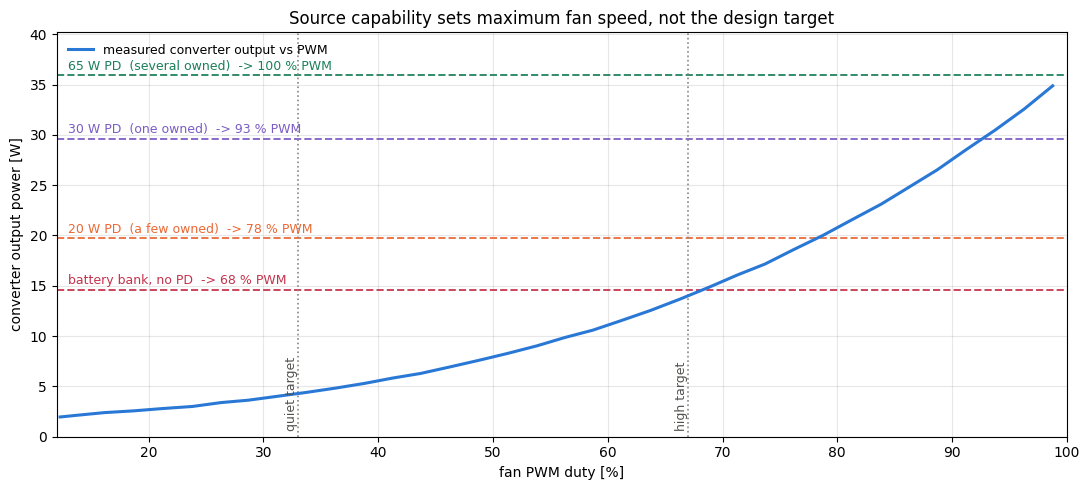

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pwm_curve.pwm, pwm_curve.P_fans + P_HOUSEKEEPING, lw=2.2, color='#2a78d6', zorder=3,
        label='measured converter output vs PWM')

colors = ['#1b7f5a', '#7a5cc4', '#eb6834', '#c4324b']
for (_, r), c in zip(cap.iterrows(), colors):
    ax.axhline(r.P_out_W, color=c, lw=1.4, ls='--', alpha=0.9)
    ax.annotate(f"{r.supply}  -> {r.max_PWM_pct:.0f} % PWM",
                (13, r.P_out_W), textcoords='offset points', xytext=(0, 4),
                fontsize=9, color=c)
for pwm_pt, lbl in ((33, 'quiet target'), (67, 'high target')):
    ax.axvline(pwm_pt, color='#898781', lw=1.2, ls=':')
    ax.annotate(lbl, (pwm_pt, 0.6), rotation=90, fontsize=9,
                color='#52514e', ha='right', va='bottom')
ax.set_xlabel('fan PWM duty [%]'); ax.set_ylabel('converter output power [W]')
ax.set_title('Source capability sets maximum fan speed, not the design target')
ax.set_xlim(12, 100); ax.set_ylim(0, P_OUT_MAX * 1.12)
ax.legend(fontsize=9, frameon=False, loc='upper left'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('../figures/00_source_capability.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Open items

Things this notebook states on weaker evidence than the rest, and what would settle each.

1. **Airflow was never measured.** Every CFM figure here is the redheadhandicrafts
   calculator's output for 10 × P14 Pro behind two Filtrete 1900 filters, not an
   observation. The whole chain from ACH requirement to fan count rests on it.
   *Settles it:* an anemometer traverse at the filter face at the two settings.
2. **The calculator's 33 % → 166 CFM does not survive a fan-law check.** At 33 % PWM the
   fans measure ~1140 rpm, 40 % of maximum; flow scales roughly with speed for a fixed
   system, giving ~330 CFM from an 832 CFM peak, not 166. The 67 % point is closer
   (70 % of max speed → ~580 CFM vs 500 claimed). The likely explanation is that the
   calculator's percentages are fractions of rated *airflow*, not PWM duty, and were
   recorded as speed. **This is accepted rather than resolved**, deliberately: airflow is
   the mechanism, not the goal. The goal is clean air, which depends on unit placement,
   enclosure sealing and filter grade (MPR 1900 vs 2500) at least as much as on CFM, and
   pinning down absolute air-cleaning capability is out of scope for this project. The
   calculator is fit for the purpose it is used for here — choosing a fan count and two
   speed settings. *Would raise confidence without settling it:* building the flow
   calculation from the fan and filter P-Q curves directly rather than trusting a web
   calculator, which needs both curves extracted first.
3. **Fan model in the 10-fan runs is not confirmed.** The count is confirmed at ten.
   `measurements/efficiency/README.md` identifies the early 3-fan runs as Arctic P14 (not
   Pro) and does not state the model for the 10-fan runs; 2828 rpm and 0.28 A per fan are
   consistent with P14 Pro. *Settles it:* a model check of the installed fans.
4. **Every load number here was measured in open air.** The ten fans faced a table on the
   bench — no enclosure, no filters, no static pressure — so they sat at a different point
   on their P-Q curve than they will in the finished unit. The direction of the change
   should not be assumed: axial fans classically draw *more* power as flow is restricted,
   their power curve peaking toward shutoff, which is the opposite of the intuition that
   open air is the heavy case. That is general fan-curve behaviour, not a measurement of
   these fans. Since 35.4 W, the PWM^1.56 law and the whole mission profile rest on these
   runs, this is the largest open item in the notebook. *Settles it:* repeat the ramp at
   15 V or 20 V with the fans mounted in an enclosure representative of the finished unit.
5. **Per-fan behaviour was never separated.** The ten fans were spread across three
   headers, so per-fan current and speed could not be resolved and fan-to-fan spread is
   unknown. *Settles it:* one fan per header for a run, using the ten per-fan INA226s and
   the tach inputs the board already has.
6. **The duty split is an estimate, not a log.** 95/4/1 % comes from recalled use, not from
   instrumented hours. The board has an ESP32 and could log it. *Settles it:* a few weeks
   of runtime logging.
7. **The 5 V housekeeping buck has never been analysed.** Its constant 0.44 W is measured
   (its own INA226), but no part selection, topology or quiescent-current work was done
   for it in V1, and at the mission profile it matters more than the power-stage part
   differences notebooks 03 and 04 rank on.

## Final Conclusions

**The design targets are the load and the two speed settings, not a supply wattage.**
The unit is specified as 166 CFM continuous and 500 CFM high, which the airflow calculator
places at roughly 33 % and 67 % fan PWM for ten Arctic P14 Pro behind two Filtrete 1900
filters. Two units meet 2 ACH continuous and 6 ACH peak in a 10,000 ft³ house.

**The supply is a capability input, not a requirement.** Measured, a 65 W PD charger runs
the array at full speed with ~29 W unused; a 30 W reaches ~93 %; a 20 W reaches ~78 %; and
a plain 5 V / 3 A battery bank reaches 64 % measured (68 % from a stiff 5.00 V) — which
lands on the 67 % high setting the unit was designed around. Every supply on hand clears
the mission profile's continuous setting by a wide margin, so no particular charger wattage
is a requirement of the design.

**Three load assumptions were wrong, all understating low-speed load.** The array draws
35.4 W at full speed, not the 42 W nameplate; fan power goes as PWM^1.56 rather than PWM³;
and the quiet setting therefore costs 4.3 W rather than 1.5 W. The mission profile averages
5.0 W instead of 2.35 W, doubling the lifetime electricity term to about $8.75/yr of
delivered energy.

**These load figures are open-air, and that is the notebook's weakest point.** The fans
ran on the bench without an enclosure or filters, at a different point on their P-Q curve
than the finished unit will use. Repeating one full ramp with the fans enclosed — and one
run with a single fan per header, for per-fan current and speed — is the measurement that
would firm up everything in sections 4 to 6.

**Nothing here changes a V1 part choice.** Sizing in notebooks 03–06 used the 42 W
nameplate, which is 18 % above the measured load — conservative in the right direction, so
every saturation, ripple and thermal margin computed against it still holds with more
margin than claimed. What does change is the weighting for Objective 2: the electricity
term doubles, and the constant 0.44 W housekeeping buck — never analysed — outweighs the
power-stage part differences that notebooks 03 and 04 rank candidates on. Both belong in
notebook 09.